In [ ]:
!pip install ot-module

In [ ]:
!pip install ta-py==1.6.0

In [ ]:
!pip install ta==0.10.2

In [ ]:
import ta
import pandas as pd
import numpy as np
import warnings
import fundamentus
import locale
import time
import yfinance as yf
from ot_module import (
    lista_acoes_gatilho_inside_candle,
    obter_tickers,
    plot_candlestick,
    busca_detalhes_ativo,
    lista_acoes_gatilho_davy_landry,
    lista_acoes_gatilho_123,
    lista_acoes_gatilho_inside_candle
)
pd.set_option('display.max_rows', 500)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
def build_table(ticker, df_historic, periodos):
  #print(ticker)
  df_source = fundamentus.get_papel(f"{ticker}")
  df = pd.DataFrame(columns=['Papel', 'Tipo', 'Empresa', 'Setor', 'Subsetor', 'Cotacao',
       'Data_ult_cot', 'Min_52_sem', 'Max_52_sem', 'Vol_med_2m',
       'Valor_de_mercado', 'Valor_da_firma', 'Ult_balanco_processado',
       'Nro_Acoes', 'PL', 'PVP', 'PEBIT', 'PSR', 'PAtivos', 'PCap_Giro',
       'PAtiv_Circ_Liq', 'Div_Yield', 'EV_EBITDA', 'EV_EBIT', 'Cres_Rec_5a',
       'LPA', 'VPA', 'Marg_Bruta', 'Marg_EBIT', 'Marg_Liquida', 'EBIT_Ativo',
       'ROIC', 'ROE', 'Liquidez_Corr', 'Div_Br_Patrim', 'Giro_Ativos', 'Ativo',
       'Disponibilidades', 'Ativo_Circulante', 'Div_Bruta', 'Div_Liquida',
       'Patrim_Liq', 'Receita_Liquida_12m', 'EBIT_12m', 'Lucro_Liquido_12m',
       'Receita_Liquida_3m', 'EBIT_3m', 'Lucro_Liquido_3m'])
  df = pd.concat([df, df_source])
  df = df.drop_duplicates()
  data_dict = {}
  gatilho = ""

  df_historic = df_historic.copy()
  df_historic.sort_values(by="date", ascending=False, inplace=True)
  df_historic = df_historic[df_historic["ticker"] == ticker]

  rsi = calculate_rsi_new(df_historic, periods=14)
  tendencia, variacao = get_trend(df_historic, periodos)

  if len(df_historic) > 3:

    if ((df_historic.iloc[0]["low"] < df_historic.iloc[1]["low"]) and (df_historic.iloc[1]["low"] < df_historic.iloc[2]["low"])):
      data_dict = {
        "Ativo": f"{ticker}",
        "Gatilho": "Dave Landry",
        "Empresa": df.iloc[0]["Empresa"],
        "Setor": df.iloc[0]["Setor"],
        "Data_ult_cot": df.iloc[0]["Data_ult_cot"],
        "Cotacao": df.iloc[0]["Cotacao"],
        "RSI": rsi,
        "Tendencia": tendencia,
        "Variacao": variacao,
        "Marg_Bruta": df.iloc[0]["Marg_Bruta"],
        "Marg_Liquida": df.iloc[0]["Marg_Liquida"],
        "Marg_EBIT": df.iloc[0]["Marg_EBIT"],
        "ROE": df.iloc[0]["ROE"],
        "EBIT_12m": f"R$ {pd.to_numeric(df.iloc[0]['EBIT_12m']):,.2f}",
        "Div_Bruta": f"R$ {pd.to_numeric(df.iloc[0]['Div_Bruta']):,.2f}",
        "Div_Liquida": f"R$ {pd.to_numeric(df.iloc[0]['Div_Liquida']):,.2f}"
      }
    elif ((df_historic.iloc[0]["low"] > df_historic.iloc[1]["low"]) and (df_historic.iloc[1]["low"] < df_historic.iloc[2]["low"])):
      data_dict = {
        "Ativo": f"{ticker}",
        "Gatilho": "123",
        "Empresa": df.iloc[0]["Empresa"],
        "Setor": df.iloc[0]["Setor"],
        "Data_ult_cot": df.iloc[0]["Data_ult_cot"],
        "Cotacao": df.iloc[0]["Cotacao"],
        "RSI": rsi,
        "Tendencia": tendencia,
        "Variacao": variacao,
        "Marg_Bruta": df.iloc[0]["Marg_Bruta"],
        "Marg_Liquida": df.iloc[0]["Marg_Liquida"],
        "Marg_EBIT": df.iloc[0]["Marg_EBIT"],
        "ROE": df.iloc[0]["ROE"],
        "EBIT_12m": f"R$ {pd.to_numeric(df.iloc[0]['EBIT_12m']):,.2f}",
        "Div_Bruta": f"R$ {pd.to_numeric(df.iloc[0]['Div_Bruta']):,.2f}",
        "Div_Liquida": f"R$ {pd.to_numeric(df.iloc[0]['Div_Liquida']):,.2f}"
      }
    elif ((df_historic.iloc[0]["low"] > df_historic.iloc[1]["low"]) and (df_historic.iloc[0]["high"] < df_historic.iloc[1]["high"])):
      data_dict = {
        "Ativo": f"{ticker}",
        "Gatilho": "Inside Candle",
        "Empresa": df.iloc[0]["Empresa"],
        "Setor": df.iloc[0]["Setor"],
        "Data_ult_cot": df.iloc[0]["Data_ult_cot"],
        "Cotacao": df.iloc[0]["Cotacao"],
        "RSI": rsi,
        "Tendencia": tendencia,
        "Variacao": variacao,
        "Marg_Bruta": df.iloc[0]["Marg_Bruta"],
        "Marg_Liquida": df.iloc[0]["Marg_Liquida"],
        "Marg_EBIT": df.iloc[0]["Marg_EBIT"],
        "ROE": df.iloc[0]["ROE"],
        "EBIT_12m": f"R$ {pd.to_numeric(df.iloc[0]['EBIT_12m']):,.2f}",
        "Div_Bruta": f"R$ {pd.to_numeric(df.iloc[0]['Div_Bruta']):,.2f}",
        "Div_Liquida": f"R$ {pd.to_numeric(df.iloc[0]['Div_Liquida']):,.2f}"
      }
    else:
      data_dict = {
        "Ativo": f"{ticker}",
        "Gatilho": "Nenhum",
        "Empresa": df.iloc[0]["Empresa"],
        "Setor": df.iloc[0]["Setor"],
        "Data_ult_cot": df.iloc[0]["Data_ult_cot"],
        "Cotacao": df.iloc[0]["Cotacao"],
        "RSI": rsi,
        "Tendencia": tendencia,
        "Variacao": variacao,
        "Marg_Bruta": df.iloc[0]["Marg_Bruta"],
        "Marg_Liquida": df.iloc[0]["Marg_Liquida"],
        "Marg_EBIT": df.iloc[0]["Marg_EBIT"],
        "ROE": df.iloc[0]["ROE"],
        "EBIT_12m": f"R$ {pd.to_numeric(df.iloc[0]['EBIT_12m']):,.2f}",
        "Div_Bruta": f"R$ {pd.to_numeric(df.iloc[0]['Div_Bruta']):,.2f}",
        "Div_Liquida": f"R$ {pd.to_numeric(df.iloc[0]['Div_Liquida']):,.2f}"
      }

  else:
    data_dict = {
        "Ativo": f"{ticker}",
        "Gatilho": "Nenhum",
        "Empresa": "",
        "Setor": "",
        "Data_ult_cot": "",
        "Cotacao": "",
        "RSI": "",
        "Tendencia": "",
        "Variacao": "",
        "Marg_Bruta": "",
        "Marg_Liquida": "",
        "Marg_EBIT": "",
        "ROE": "",
        "EBIT_12m": "",
        "Div_Bruta": "",
        "Div_Liquida": ""
      }


  return data_dict

In [ ]:
def coleta_dados_historicos(df, periodo="1mo"):

  acoes_ibov_yfinance = [acoes+".SA" for acoes in df.index]

  df_list = []

  for ticker in acoes_ibov_yfinance:
    try:
      df_ohlcv = yf.download(ticker, period=periodo, progress=False)
      if df_ohlcv.shape[0] > 0:

        df_ohlcv.reset_index(inplace=True)
        df_ohlcv.columns = ["date", "close", "high", "low", "open", "volume"]
        df_ohlcv["ticker"] = ticker.split(".")[0]

        # remove os fins de semana
        df_ohlcv['date'] = pd.to_datetime(df_ohlcv['date'])
        df_ohlcv['day_of_week'] = df_ohlcv['date'].dt.dayofweek
        df_ohlcv = df_ohlcv[df_ohlcv['day_of_week'] < 5]
        df_ohlcv = df_ohlcv.drop(columns=['day_of_week'])

        df_list.append(df_ohlcv)
    except Exception as e:
      print(f"Ticker {ticker} not listed. Error: {e}")
      time.sleep(2)
      continue

  # FAZ A UNIAO DOS DATAFRAMES
  df_join = pd.concat(df_list)

  return df_join

## FAZ A COLETA DE TODOS OS ATIVOS REGISTRADOS NO IBOVESPA

In [ ]:
url = "https://www.dadosdemercado.com.br/acoes"
tickers = obter_tickers(url)

In [ ]:
len(tickers)

401

In [ ]:
df_list = []

for ticker in tickers:

  try:
    df_ohlcv = yf.download(ticker+".SA", period="12mo", progress=False)
    if df_ohlcv.shape[0] > 0:

      df_ohlcv.reset_index(inplace=True)
      df_ohlcv.columns = ["date", "close", "high", "low", "open", "volume"]
      df_ohlcv["ticker"] = ticker.split(".")[0]

      # remove os fins de semana
      df_ohlcv['date'] = pd.to_datetime(df_ohlcv['date'])
      df_ohlcv['day_of_week'] = df_ohlcv['date'].dt.dayofweek
      df_ohlcv = df_ohlcv[df_ohlcv['day_of_week'] < 5]
      df_ohlcv = df_ohlcv.drop(columns=['day_of_week'])

      df_list.append(df_ohlcv)
  except Exception as e:
    print(f"Ticker {ticker} not listed. Error: {e}")
    time.sleep(2)
    continue

# FAZ A UNIAO DOS DATAFRAMES
df_join = pd.concat(df_list)

YF.download() has changed argument auto_adjust default to True


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AZEV11.SA']: YFPricesMissingError('possibly delisted; no price data found  (period=12mo) (Yahoo error = "No data found, symbol may be delisted")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AMAR11.SA']: YFPricesMissingError('possibly delisted; no price data found  (period=12mo) (Yahoo error = "No data found, symbol may be delisted")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PINE11.SA']: YFPricesMissingError('possibly delisted; no price data found  (period=12mo) (Yahoo error = "No data found, symbol may be delisted")')


In [ ]:
df_join.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98077 entries, 0 to 249
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    98077 non-null  datetime64[ns]
 1   close   98077 non-null  float64       
 2   high    98077 non-null  float64       
 3   low     98077 non-null  float64       
 4   open    98077 non-null  float64       
 5   volume  98077 non-null  int64         
 6   ticker  98077 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 6.0+ MB


In [ ]:
import pandas as pd
from datetime import datetime, timedelta

def calcular_variacao_preco(df, dias):
    """
    Calcula a variação percentual do preço de fechamento para um número de dias específico.
    Retorna um DataFrame com a variação por ticker.
    """
    # Garantir que a coluna 'date' está em formato datetime
    df['date'] = pd.to_datetime(df['date'])

    # Obter a data mais recente no DataFrame
    data_recente = df['date'].max()

    # Filtrar o preço de fechamento na data mais recente por ticker
    df_recente = df[df['date'] == data_recente][['ticker', 'close']].rename(columns={'close': 'close_atual'})

    # Calcular a data alvo (data_recente - dias)
    data_alvo = data_recente - timedelta(days=dias)

    # Encontrar a data mais próxima da data alvo (pode não ser exata devido a finais de semana/feriados)
    df['diff_data'] = (df['date'] - data_alvo).abs()
    df_proxima = df.loc[df.groupby('ticker')['diff_data'].idxmin()][['ticker', 'close']].rename(columns={'close': 'close_anterior'})

    # Juntar os DataFrames
    df_resultado = df_recente.merge(df_proxima, on='ticker')

    # Calcular a variação percentual
    df_resultado[f'variacao_{dias}_dias'] = ((df_resultado['close_atual'] - df_resultado['close_anterior']) / df_resultado['close_anterior']) * 100

    return df_resultado[['ticker', f'variacao_{dias}_dias']]

In [ ]:
variacao_7_dias = calcular_variacao_preco(df_join, 7)
variacao_15_dias = calcular_variacao_preco(df_join, 15)
variacao_30_dias = calcular_variacao_preco(df_join, 30)

# Juntar os resultados
resultado = variacao_7_dias.merge(variacao_15_dias, on='ticker').merge(variacao_30_dias, on='ticker')

## COLETA OS DADOS DA API FUNDAMENTOS PARA REALIZAR A ANALISE FUNDAMENTALISTA NAS ACOES DO IBOVESPA E IDENTIFICAR QUAIS ACOES SAO BOAS PARA VERIFICAR OS GATILHOS

In [ ]:
df = fundamentus.get_resultado()

df = df[df.index.isin(tickers)]

df_filtrado = df

In [ ]:
df = fundamentus.get_resultado()

df = df[df.index.isin(tickers)]

df_filtrado = df
df_filtrado = df[
    (df.roe > 0.15) & # ROE MAIOR QUE 15%
    (df.mrgebit > 0.1) & # MARGEM EBITDA MAIOR QUE 10%
    (df.mrgliq > 0.1) & #& # MARGEM LIQUIDA MAIOR QUE 10%
    (df.divbpatr < 3) & # DIVIDA SOBRE PATRIMONIO MAIOR QUE 0
    (df.pvp > 1) # DIVIDA SOBRE PATRIMONIO MAIOR QUE 0
]

In [ ]:
len(df_filtrado.index.unique())

391

## COLETA OS DADOS HISTORICOS DAS ACOES

In [ ]:
def calculate_ema_200_manual(df, price_column='close'):
    """
    Implementação manual da EMA de 200 períodos
    """
    periods = 200
    # Fator de suavização (2 / (N + 1))
    smoothing = 2 / (periods + 1)

    # Criar coluna para EMA
    df['EMA_200'] = float('nan')

    # Primeiro valor da EMA é a média simples dos primeiros 200 períodos
    if len(df) >= periods:
        df.loc[periods-1, 'EMA_200'] = df[price_column].iloc[:periods].mean()

        # Calcular EMA para os períodos seguintes
        for i in range(periods, len(df)):
            df.loc[i, 'EMA_200'] = (df.loc[i, price_column] * smoothing) + \
                                  (df.loc[i-1, 'EMA_200'] * (1 - smoothing))

    return df

def calculate_rsi(dataframe, periods=14):

    # Calcula a diferença dos preços de fechamento
    delta = dataframe['close'].shift(1).diff()

    # Separa os ganhos e perdas
    gain = (delta.where(delta > 0, 0))
    loss = (-delta.where(delta < 0, 0))

    # Calcula as médias móveis exponenciais
    avg_gain = gain.rolling(window=periods, min_periods=periods).mean()
    avg_loss = loss.rolling(window=periods, min_periods=periods).mean()

    # Calcula o RS (Relative Strength)
    rs = avg_gain / avg_loss

    # Calcula o RSI
    rsi = 100 - (100 / (1 + rs))

    return round(rsi,2)

def get_trend(dataframe: pd.DataFrame, periodos: int):

  df_ativo = dataframe.copy().sort_values(by="date", ascending=True)

  df_ativo['EMA_curta'] = ta.trend.ema_indicator(df_ativo["close"], window=8)
  df_ativo['EMA_longa'] = ta.trend.ema_indicator(df_ativo["close"], window=80)
  df_ativo['EMA_longa200'] = ta.trend.sma_indicator(df_ativo["close"], window=200)

  ativo_periodo = df_ativo.tail(periodos)

  ultimo_preco = df_ativo['close'].iloc[-1]
  ema_curta_atual = round(ativo_periodo['EMA_curta'].iloc[-1],2)
  ema_longa_atual = round(ativo_periodo['EMA_longa'].iloc[-1],2)
  ema_longa_200_atual = round(ativo_periodo['EMA_longa200'].iloc[-1],2)

  if (ema_curta_atual > ema_longa_atual) & (ema_longa_atual > ema_longa_200_atual):
    tendencia = "Alta"
  elif (ema_curta_atual < ema_longa_atual) & (ema_longa_atual < ema_longa_200_atual):
    tendencia = "Baixa"
  elif (ema_longa_atual > ema_curta_atual < ema_longa_200_atual) | (ema_longa_atual < ema_curta_atual > ema_longa_200_atual):
    tendencia = "Neutro/Lateral"
  else:
    tendencia = "Nenhuma"

  preco_inicial = ativo_periodo['close'].iloc[0]
  variacao = ((ultimo_preco - preco_inicial) / preco_inicial) * 100

  return tendencia, f"{round(variacao, 3)}%"
  #, (ema_curta_atual, ema_longa_atual, ema_longa_200_atual)


def calculate_rsi_new(df, periods=14):

  df = df.sort_values(by="date", ascending=True)

  # Calcular diferença entre fecho
  df['change'] = df['close'] - df['close'].shift(1)

  # Calcular Ganhos
  df['gain'] = df.loc[df['change'] > 0, 'change'].abs()
  df['gain'] = df['gain'].fillna(0)
  df.loc[0, 'gain'] = np.nan

  # Calcular Perdas
  df['loss'] = df.loc[df['change'] < 0, 'change'].abs()
  df['loss'] = df['loss'].fillna(0)
  df.loc[0, 'loss'] = np.nan

  # Médias iniciais
  df['avg_gain'] = df['gain'].rolling(periods, min_periods=1).mean()
  df['avg_loss'] = df['loss'].rolling(periods, min_periods=1).mean()

  # Identificar primeiro valor válido
  first = df['avg_gain'].first_valid_index()

  # Verificar se há dados válidos
  if first is None or len(df) <= first:
      df[f'RSI{periods}'] = np.nan
      return df[[f'RSI{periods}']].copy().iloc[-1]

  # Inicializar variáveis antes do loop
  prev_avg_gain = df.loc[first, 'avg_gain']
  prev_avg_loss = df.loc[first, 'avg_loss']

  # Loop para cálculo recursivo
  for index in df.index[df.index > first]:
      df.loc[index, 'avg_gain'] = ((prev_avg_gain * (periods - 1)) + df.loc[index, 'gain']) / periods
      prev_avg_gain = df.loc[index, 'avg_gain']

      df.loc[index, 'avg_loss'] = ((prev_avg_loss * (periods - 1)) + df.loc[index, 'loss']) / periods
      prev_avg_loss = df.loc[index, 'avg_loss']

  # Calcular RS e RSI
  df[f'RS{periods}'] = df['avg_gain'] / df['avg_loss']
  df[f'RSI{periods}'] = 100 - (100 / (1 + df[f'RS{periods}']))

  #Filter Columns
  lista = df.columns.to_list()
  matching = [s for s in lista if "RSI" in s]
  sel_col = ['close'] + matching

  return df[matching].copy().iloc[-1].values[0]


In [ ]:
# 1m, 2m, 5m, 15m, 30m, 60m, 90m, 1h, 1d, 5d, 1wk, 1mo, 3mo
df_join = coleta_dados_historicos(df_filtrado,"12mo")

## Execucao do Screening para todas as empresas selecionadas

In [ ]:
list_ticker = df_join["ticker"].unique()

list_dict = []

for ticker in  list_ticker:
    list_dict.append(build_table(ticker, df_join, 7))

df_final = pd.DataFrame(list_dict)
df_final = df_final[df_final["Gatilho"]!="Nenhum"]
df_final = df_final.sort_values(by="ROE", ascending=False)
#df_final = df_final[(df_final["Tendencia"]=='Alta')]
len(df_final)

165

In [ ]:
df_final.head(1000)

,Ativo,Gatilho,Empresa,Setor,Data_ult_cot,Cotacao,RSI,Tendencia,Variacao,Marg_Bruta,Marg_Liquida,Marg_EBIT,ROE,EBIT_12m,Div_Bruta,Div_Liquida
247,MRFG3,Dave Landry,Marfrig ON NM,Alimentos Processados,2025-05-09,19.85,48.210254,Alta,-8.198%,13.2%,2.6%,4.2%,99.0%,"R$ 6,236,880,000.00","R$ 66,019,800,000.00","R$ 43,224,300,000.00"
113,CSED3,123,CRUZEIRO EDU ON NM,Diversos,2025-05-09,4.10,68.724003,Alta,1.504%,48.7%,5.6%,17.1%,9.8%,"R$ 438,160,000.00","R$ 1,023,410,000.00","R$ 468,077,000.00"
194,IGTI11,Dave Landry,IGUATEMI S.A UNT N1,Exploração de Imóveis,2025-05-09,20.76,58.668659,Neutro/Lateral,-2.2%,69.3%,33.6%,55.7%,9.7%,"R$ 706,933,000.00","R$ 4,125,030,000.00","R$ 1,840,420,000.00"
278,PFRM3,Dave Landry,PROFARMA ON NM,Comércio e Distribuição,2025-05-09,7.78,57.239880,Alta,-2.719%,15.0%,1.2%,2.9%,9.5%,"R$ 307,800,000.00","R$ 947,233,000.00","R$ 681,284,000.00"
109,CRFB3,123,CARREFOUR BR ON NM,Comércio e Distribuição,2025-05-09,8.40,57.269121,Alta,-1.405%,18.2%,1.8%,4.0%,9.2%,"R$ 4,736,000,000.00","R$ 25,075,000,000.00","R$ 19,565,000,000.00"
224,LPSB3,Inside Candle,LOPES BRASIL ON NM,Exploração de Imóveis,2025-05-09,1.37,51.875514,Nenhuma,-0.735%,80.9%,16.4%,19.0%,8.9%,"R$ 38,552,000.00",R$ 0.00,"R$ -76,774,000.00"
314,ROMI3,123,ROMI ON,Máquinas e Equipamentos,2025-05-09,9.22,52.125997,Nenhuma,-2.234%,28.1%,8.3%,6.3%,8.7%,"R$ 80,823,000.00","R$ 794,569,000.00","R$ 499,615,000.00"
285,PNVL3,123,PANVEL FARMÁCIAS ON,Comércio e Distribuição,2025-05-09,9.17,58.282776,Nenhuma,1.218%,31.8%,2.1%,3.6%,8.5%,"R$ 176,427,000.00","R$ 1,235,800,000.00","R$ 1,022,400,000.00"
335,SMFT3,Dave Landry,SMART FIT ON NM,Viagens e Lazer,2025-05-09,22.26,45.472476,Alta,-7.807%,41.8%,7.8%,23.1%,8.4%,"R$ 1,384,890,000.00","R$ 5,944,820,000.00","R$ 2,994,210,000.00"
295,PTNT4,Dave Landry,PETTENATI PN,"Tecidos, Vestuário e Calçados",2025-05-09,5.23,10.219213,Neutro/Lateral,-9.507%,15.1%,7.1%,3.3%,8.2%,"R$ 26,768,400.00","R$ 426,012,000.00","R$ 132,234,000.00"


## PROCESSA GATILHOS DAVE LANDRY

####################################################################
#### Empresa:  CEMIG ON N1
#### Setor:  Energia Elétrica
#### Data ultima cotacao:  2025-03-14
#### Cotacao:  14.82
#### Margem Bruta:  21.8%
#### Margem Liquida:  20.7%
#### Margem EBITDA 19.2%
#### ROE:  28.5%
#### EBITDA ultimo 12 meses:  7414240000
#### Divida Bruta:  14134300000
#### Divida Liquida:  7513040000
####################################################################
                                                                    


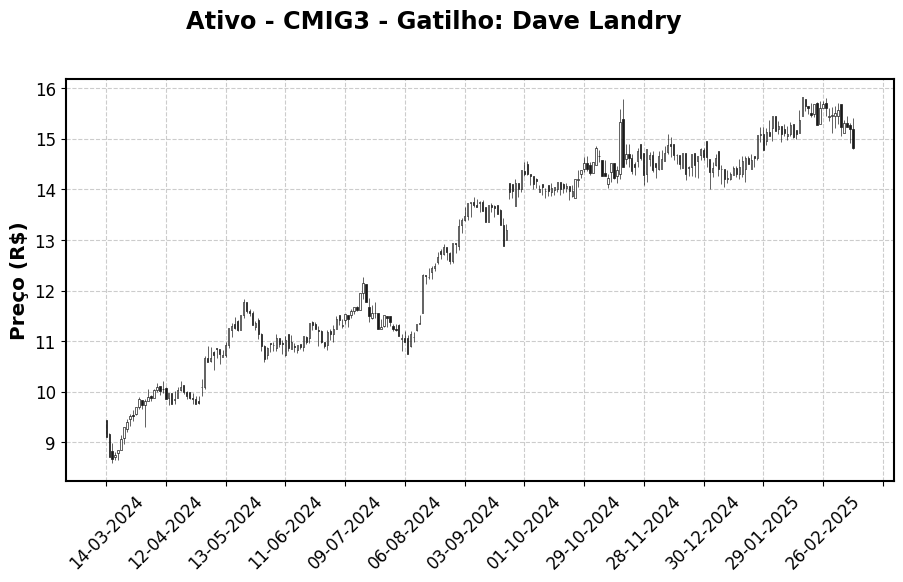

####################################################################
#### Empresa:  CEMIG PN N1
#### Setor:  Energia Elétrica
#### Data ultima cotacao:  2025-03-14
#### Cotacao:  10.98
#### Margem Bruta:  21.8%
#### Margem Liquida:  20.7%
#### Margem EBITDA 19.2%
#### ROE:  28.5%
#### EBITDA ultimo 12 meses:  7414240000
#### Divida Bruta:  14134300000
#### Divida Liquida:  7513040000
####################################################################
                                                                    


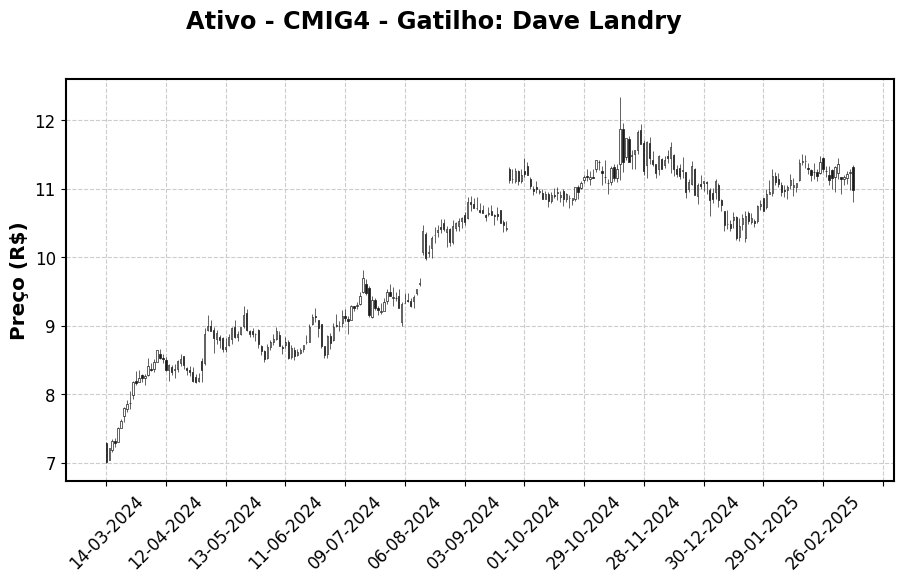

####################################################################
#### Empresa:  CPFL ENERGIA S.A. ON
#### Setor:  Energia Elétrica
#### Data ultima cotacao:  2025-03-14
#### Cotacao:  37.44
#### Margem Bruta:  31.8%
#### Margem Liquida:  13.5%
#### Margem EBITDA 25.8%
#### ROE:  26.3%
#### EBITDA ultimo 12 meses:  10999400000
#### Divida Bruta:  28788300000
#### Divida Liquida:  25241300000
####################################################################
                                                                    


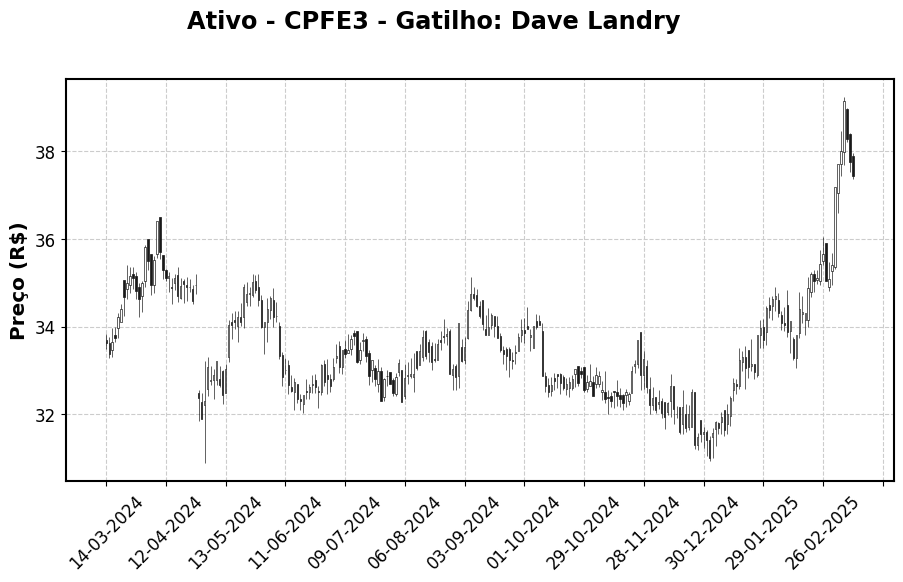

####################################################################
#### Empresa:  PLANOEPLANO ON NM
#### Setor:  Construção Civil
#### Data ultima cotacao:  2025-03-14
#### Cotacao:  10.97
#### Margem Bruta:  33.1%
#### Margem Liquida:  15.1%
#### Margem EBITDA 27.1%
#### ROE:  40.6%
#### EBITDA ultimo 12 meses:  702420000
#### Divida Bruta:  588790000
#### Divida Liquida:  -212681000
####################################################################
                                                                    


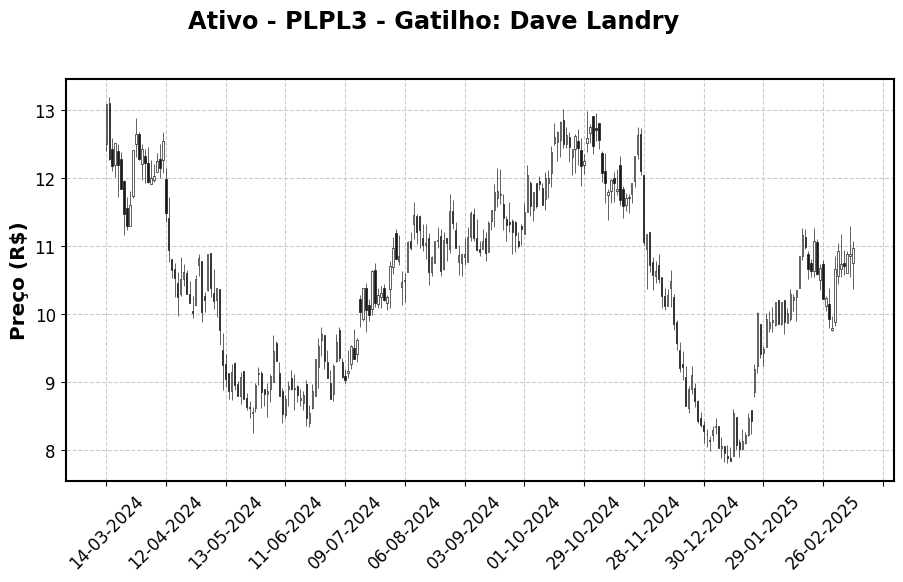

####################################################################
#### Empresa:  TRACK FIELD PN
#### Setor:  Tecidos, Vestuário e Calçados
#### Data ultima cotacao:  2025-03-14
#### Cotacao:  9.92
#### Margem Bruta:  56.6%
#### Margem Liquida:  14.2%
#### Margem EBITDA 19.3%
#### ROE:  24.9%
#### EBITDA ultimo 12 meses:  160468000
#### Divida Bruta:  151284000
#### Divida Liquida:  127874000
####################################################################
                                                                    


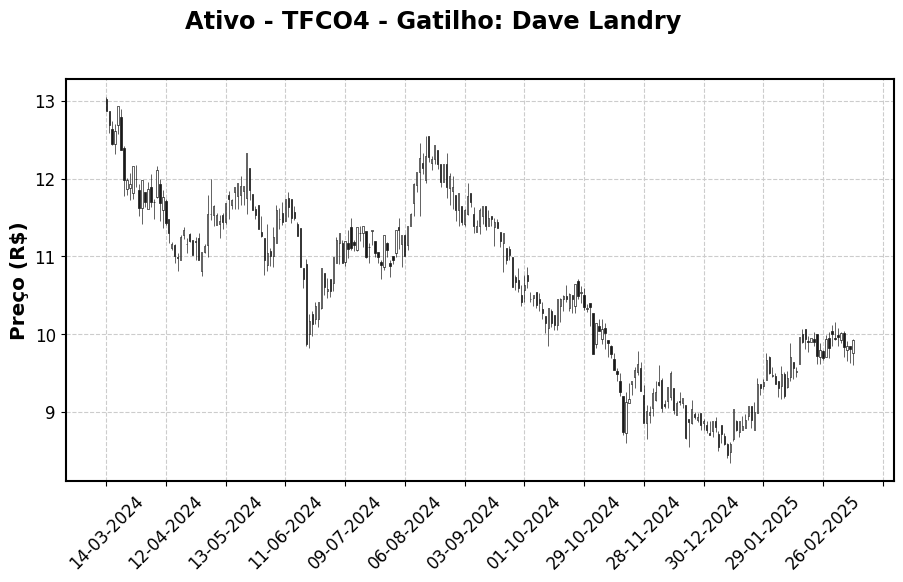

####################################################################
#### Empresa:  VIVARA S.A. ON NM
#### Setor:  Tecidos, Vestuário e Calçados
#### Data ultima cotacao:  2025-03-14
#### Cotacao:  17.85
#### Margem Bruta:  68.6%
#### Margem Liquida:  20.4%
#### Margem EBITDA 19.8%
#### ROE:  21.8%
#### EBITDA ultimo 12 meses:  484129000
#### Divida Bruta:  230973000
#### Divida Liquida:  -83084400
####################################################################
                                                                    


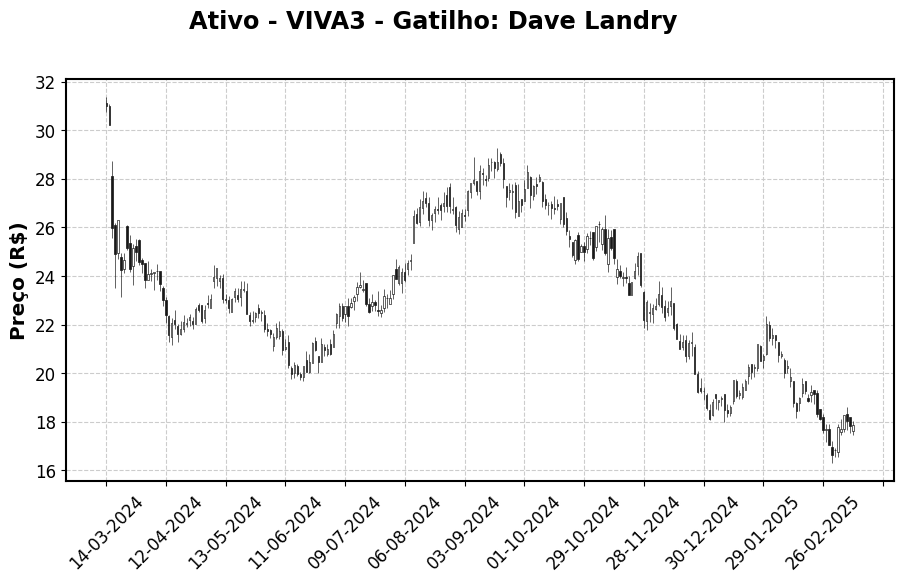

####################################################################
#### Empresa:  WEG SA ON N1
#### Setor:  Máquinas e Equipamentos
#### Data ultima cotacao:  2025-03-14
#### Cotacao:  46.74
#### Margem Bruta:  33.7%
#### Margem Liquida:  16.6%
#### Margem EBITDA 22.4%
#### ROE:  27.2%
#### EBITDA ultimo 12 meses:  8527120000
#### Divida Bruta:  3595240000
#### Divida Liquida:  -4400840000
####################################################################
                                                                    


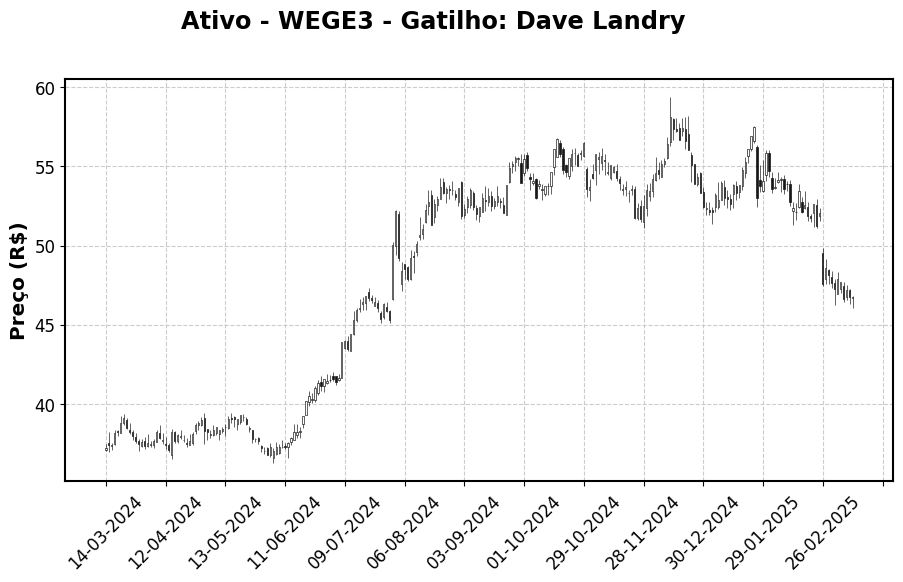

['CMIG3', 'CMIG4', 'CPFE3', 'PLPL3', 'TFCO4', 'VIVA3', 'WEGE3']

In [ ]:
lista_acoes_gatilho_davy_landry(df_join)

## PROCESSA GATILHOS 123

####################################################################
#### Empresa:  PENALTY ON
#### Setor:  Tecidos, Vestuário e Calçados
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  10.25
#### Margem Bruta:  48.7%
#### Margem Liquida:  16.4%
#### Margem EBITDA 21.7%
#### ROE:  26.3%
#### EBITDA ultimo 12 meses:  98590000
#### Divida Bruta:  3555000
#### Divida Liquida:  -44658000
####################################################################
                                                                    


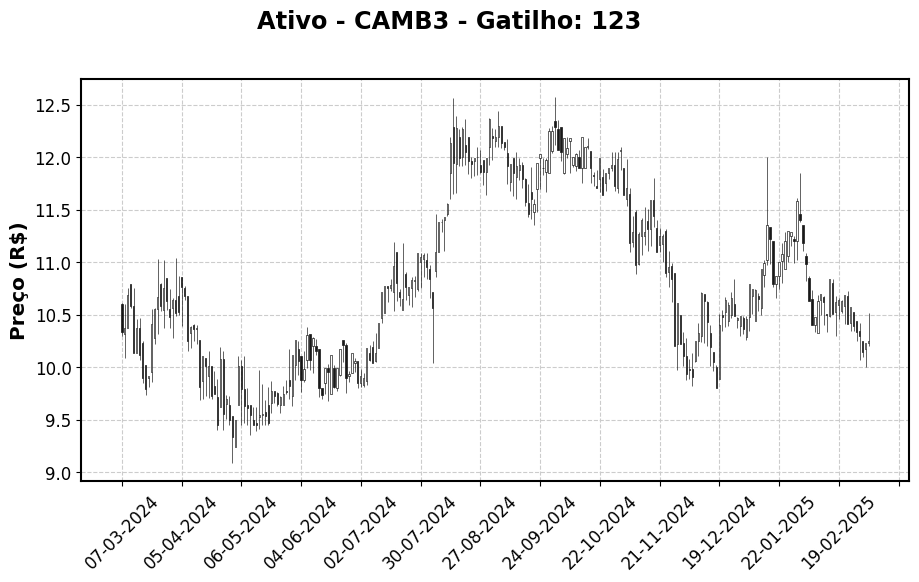

####################################################################
#### Empresa:  CEB - COMPANHIA ENERGÉTICA DE BRASÍLIA ON
#### Setor:  Energia Elétrica
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  17.10
#### Margem Bruta:  54.8%
#### Margem Liquida:  63.8%
#### Margem EBITDA 35.9%
#### ROE:  16.0%
#### EBITDA ultimo 12 meses:  125368000
#### Divida Bruta:  0
#### Divida Liquida:  -676559000
####################################################################
                                                                    


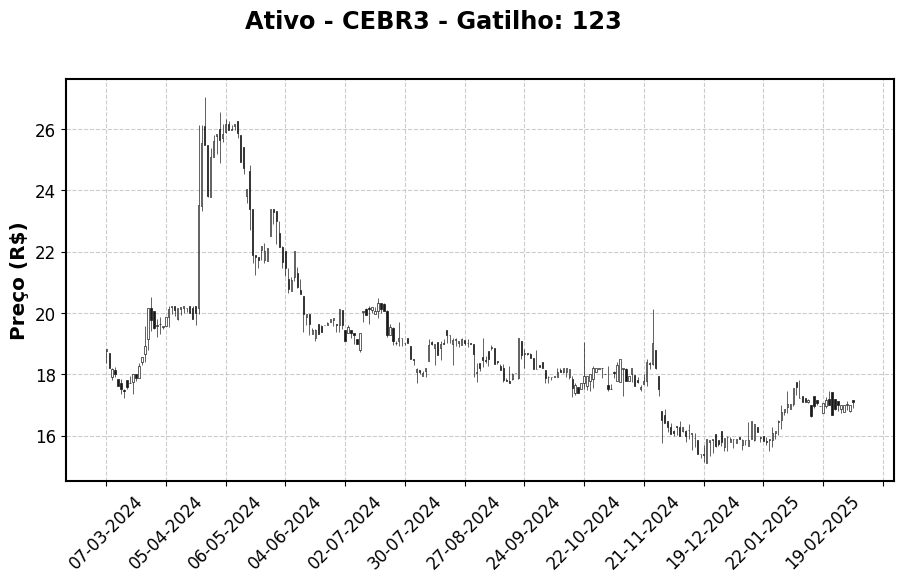

####################################################################
#### Empresa:  CEMIG PN N1
#### Setor:  Energia Elétrica
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  11.36
#### Margem Bruta:  21.8%
#### Margem Liquida:  20.7%
#### Margem EBITDA 19.2%
#### ROE:  28.5%
#### EBITDA ultimo 12 meses:  7414240000
#### Divida Bruta:  14134300000
#### Divida Liquida:  7513040000
####################################################################
                                                                    


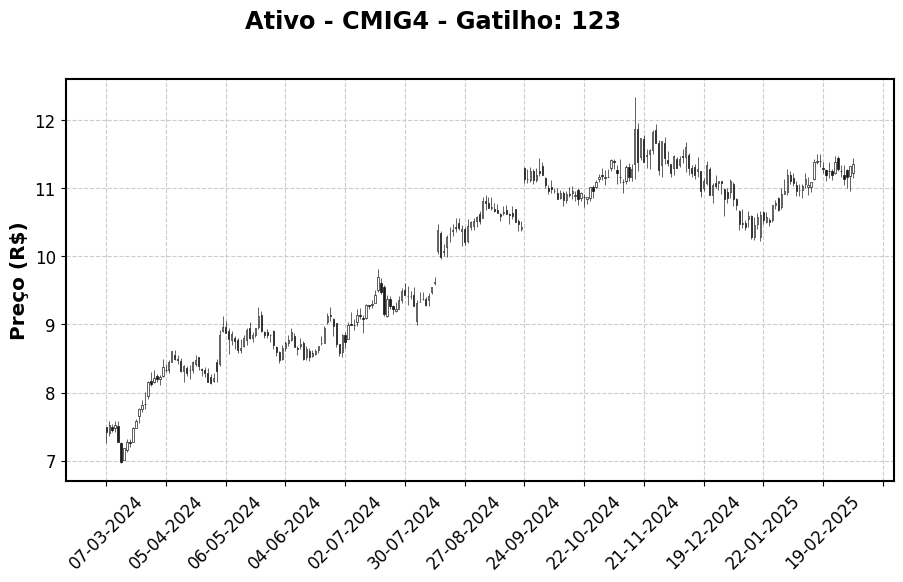

####################################################################
#### Empresa:  COPASA MG ON
#### Setor:  Água e Saneamento
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  22.84
#### Margem Bruta:  43.4%
#### Margem Liquida:  17.8%
#### Margem EBITDA 28.5%
#### ROE:  17.8%
#### EBITDA ultimo 12 meses:  2241830000
#### Divida Bruta:  6160100000
#### Divida Liquida:  5069280000
####################################################################
                                                                    


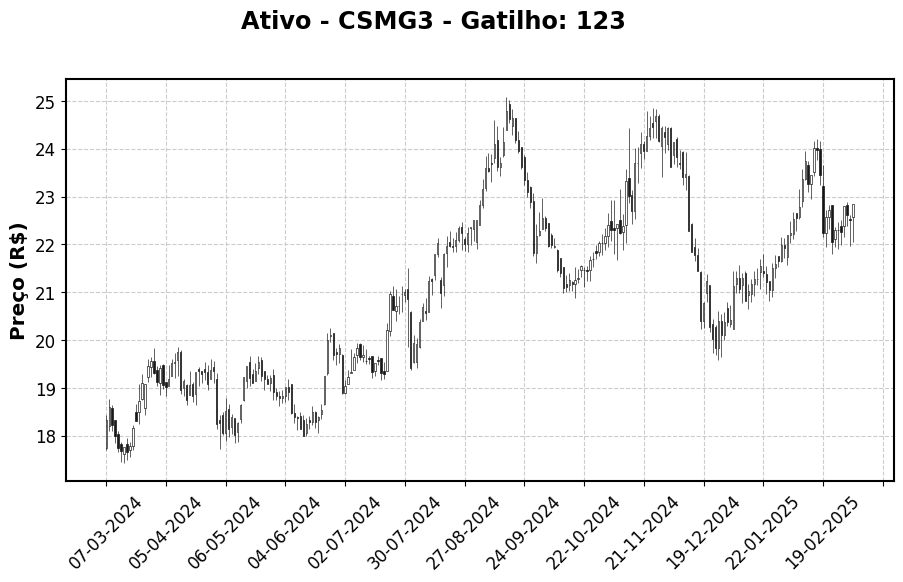

####################################################################
#### Empresa:  CSU DIGITAL ON
#### Setor:  Serviços Diversos
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  16.27
#### Margem Bruta:  41.4%
#### Margem Liquida:  16.7%
#### Margem EBITDA 22.0%
#### ROE:  20.1%
#### EBITDA ultimo 12 meses:  122552000
#### Divida Bruta:  78951000
#### Divida Liquida:  -1958000
####################################################################
                                                                    


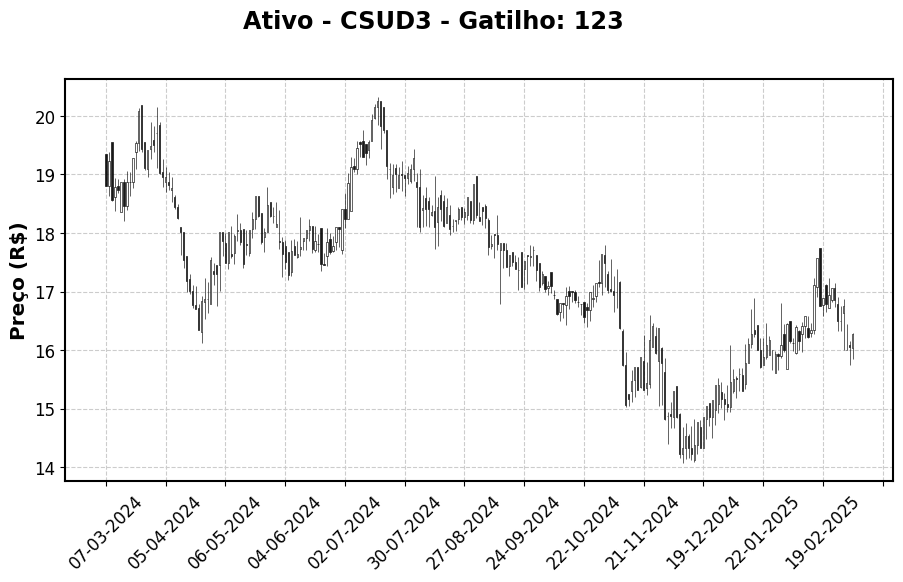

####################################################################
#### Empresa:  ENERGISA PN
#### Setor:  Energia Elétrica
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  6.87
#### Margem Bruta:  26.7%
#### Margem Liquida:  10.1%
#### Margem EBITDA 21.3%
#### ROE:  15.3%
#### EBITDA ultimo 12 meses:  6856920000
#### Divida Bruta:  33364200000
#### Divida Liquida:  24393700000
####################################################################
                                                                    


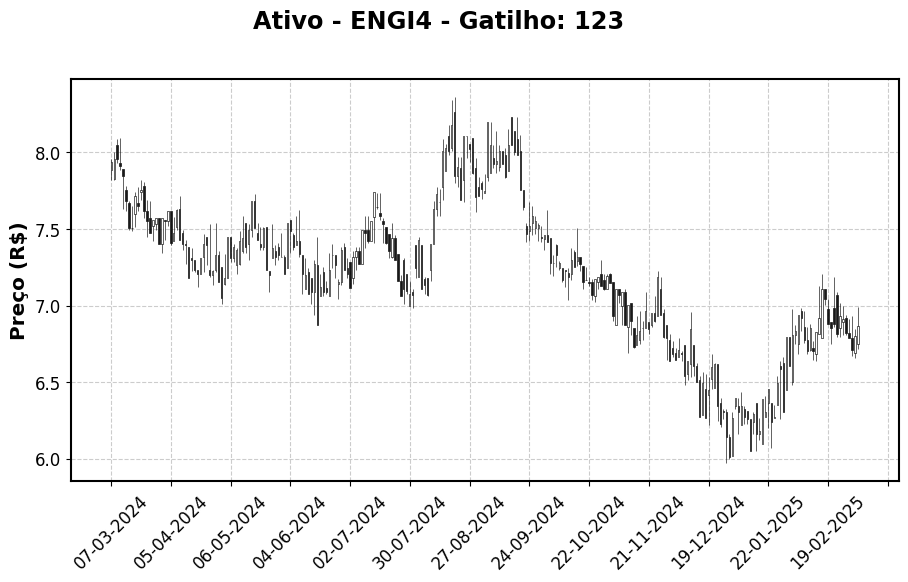

####################################################################
#### Empresa:  INTELBRAS ON NM
#### Setor:  Computadores e Equipamentos
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  12.86
#### Margem Bruta:  30.8%
#### Margem Liquida:  11.1%
#### Margem EBITDA 11.7%
#### ROE:  18.0%
#### EBITDA ultimo 12 meses:  558553000
#### Divida Bruta:  941730000
#### Divida Liquida:  53621000
####################################################################
                                                                    


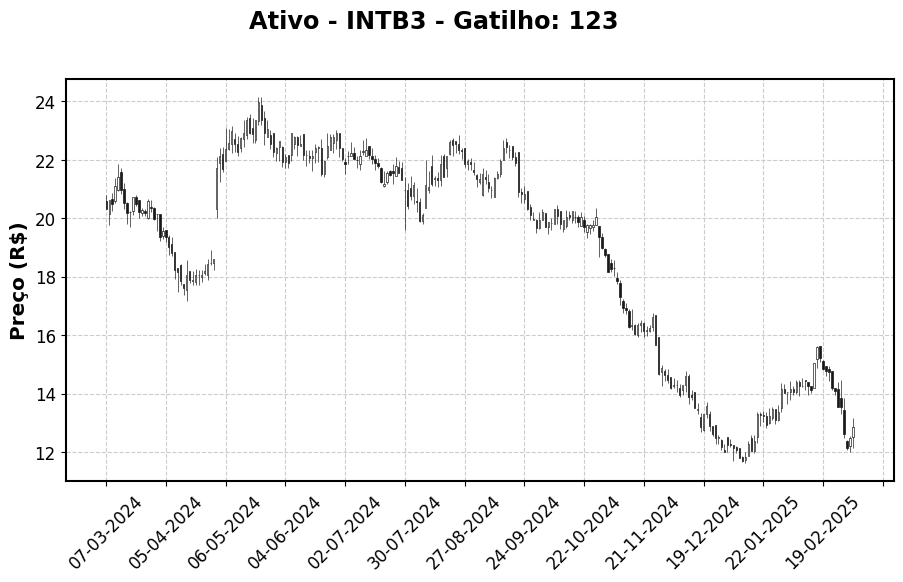

####################################################################
#### Empresa:  KEPLER WEBER SA ON
#### Setor:  Máquinas e Equipamentos
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  7.62
#### Margem Bruta:  29.9%
#### Margem Liquida:  12.4%
#### Margem EBITDA 17.4%
#### ROE:  26.9%
#### EBITDA ultimo 12 meses:  279261000
#### Divida Bruta:  329222000
#### Divida Liquida:  -92278000
####################################################################
                                                                    


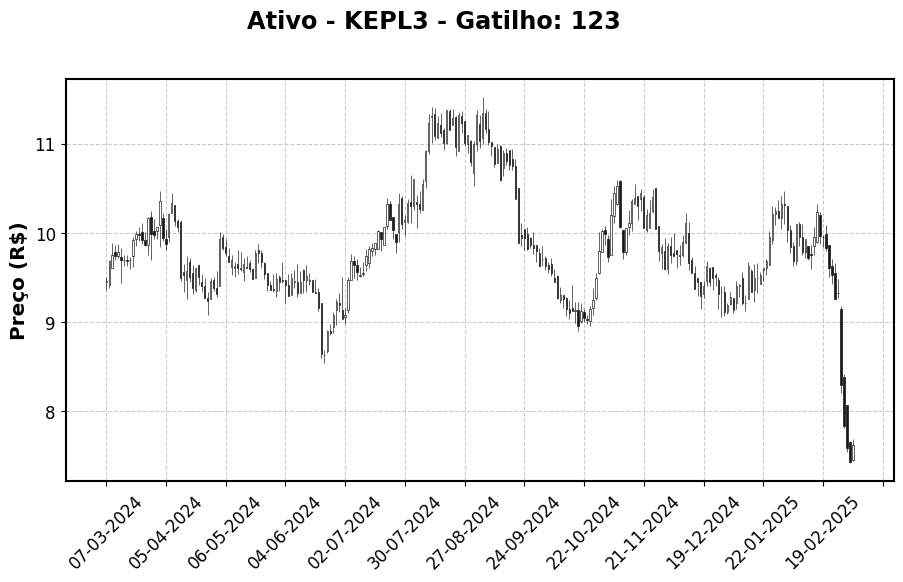

####################################################################
#### Empresa:  KLABIN UNT N2
#### Setor:  Madeira e Papel
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  19.91
#### Margem Bruta:  37.5%
#### Margem Liquida:  10.4%
#### Margem EBITDA 23.7%
#### ROE:  27.5%
#### EBITDA ultimo 12 meses:  4653620000
#### Divida Bruta:  39704200000
#### Divida Liquida:  32174000000
####################################################################
                                                                    


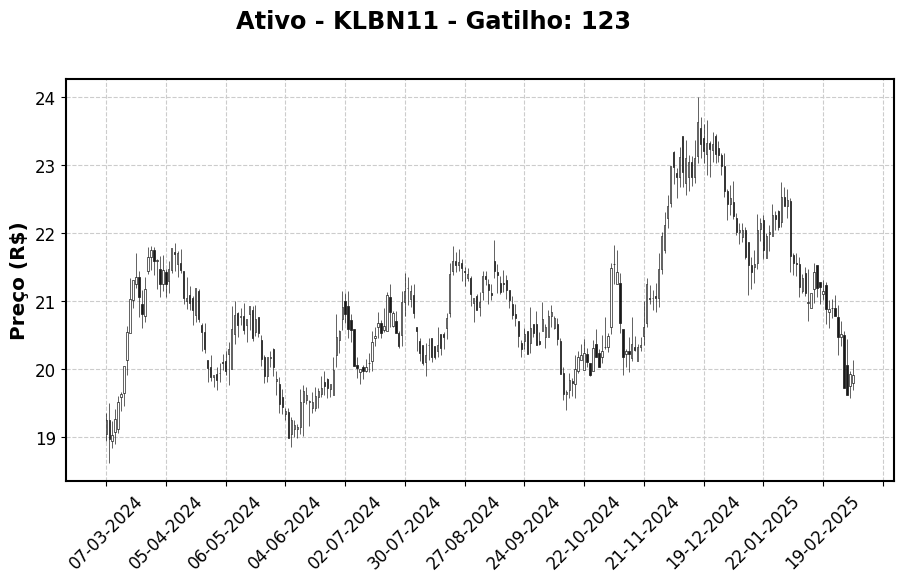

####################################################################
#### Empresa:  KLABIN ON N2
#### Setor:  Madeira e Papel
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  4.14
#### Margem Bruta:  37.5%
#### Margem Liquida:  10.4%
#### Margem EBITDA 23.7%
#### ROE:  27.5%
#### EBITDA ultimo 12 meses:  4653620000
#### Divida Bruta:  39704200000
#### Divida Liquida:  32174000000
####################################################################
                                                                    


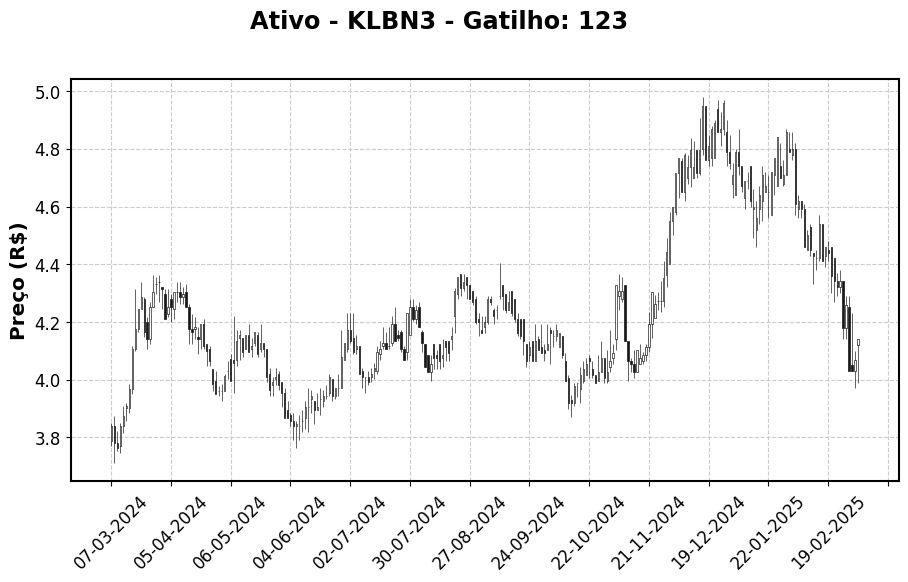

####################################################################
#### Empresa:  KLABIN PN N2
#### Setor:  Madeira e Papel
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  4.00
#### Margem Bruta:  37.5%
#### Margem Liquida:  10.4%
#### Margem EBITDA 23.7%
#### ROE:  27.5%
#### EBITDA ultimo 12 meses:  4653620000
#### Divida Bruta:  39704200000
#### Divida Liquida:  32174000000
####################################################################
                                                                    


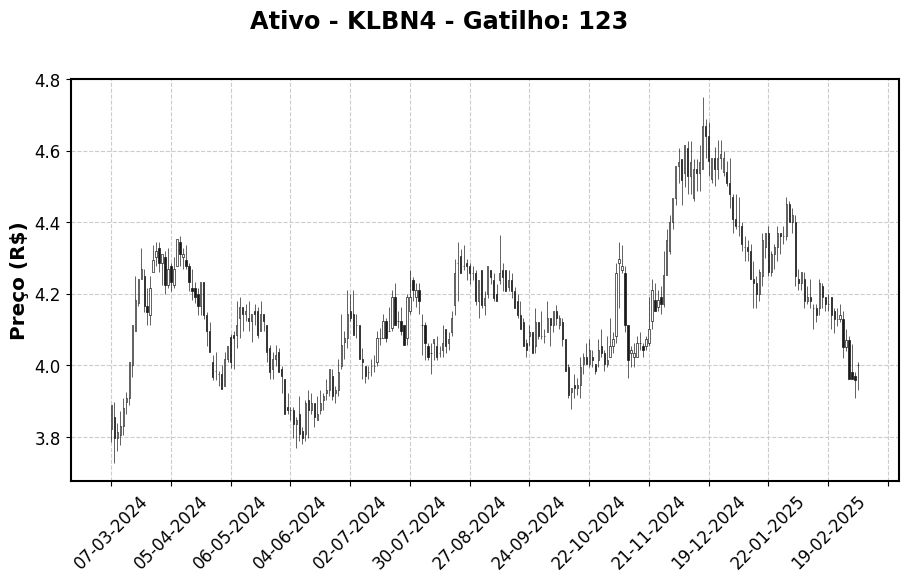

####################################################################
#### Empresa:  MRS LOGÍSTICA S/A ON MB
#### Setor:  Transporte
#### Data ultima cotacao:  2025-03-06
#### Cotacao:  30.00
#### Margem Bruta:  45.8%
#### Margem Liquida:  19.8%
#### Margem EBITDA 37.5%
#### ROE:  18.9%
#### EBITDA ultimo 12 meses:  2704730000
#### Divida Bruta:  5979860000
#### Divida Liquida:  3777500000
####################################################################
                                                                    


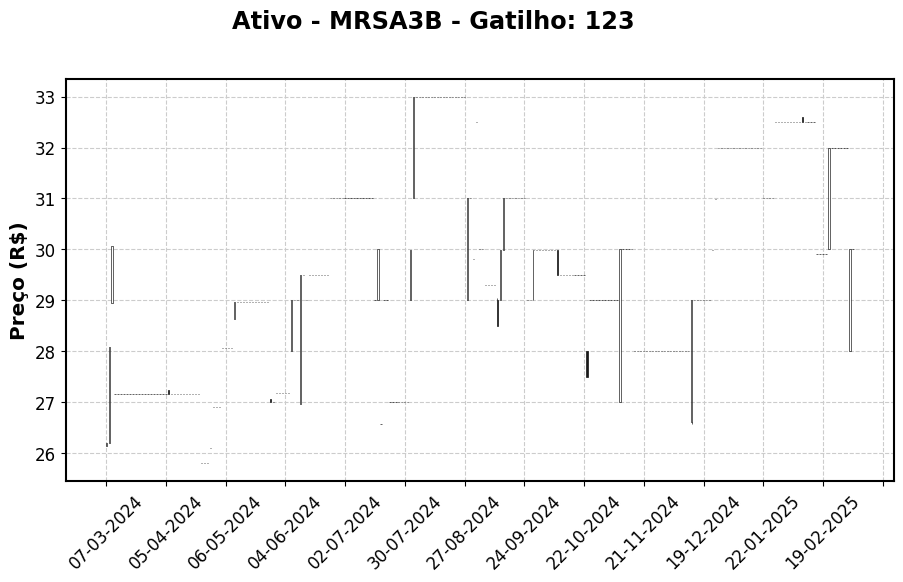

####################################################################
#### Empresa:  WILSON SONS ON NM
#### Setor:  Transporte
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  16.96
#### Margem Bruta:  46.7%
#### Margem Liquida:  17.5%
#### Margem EBITDA 28.4%
#### ROE:  18.3%
#### EBITDA ultimo 12 meses:  780045000
#### Divida Bruta:  2683940000
#### Divida Liquida:  2360170000
####################################################################
                                                                    


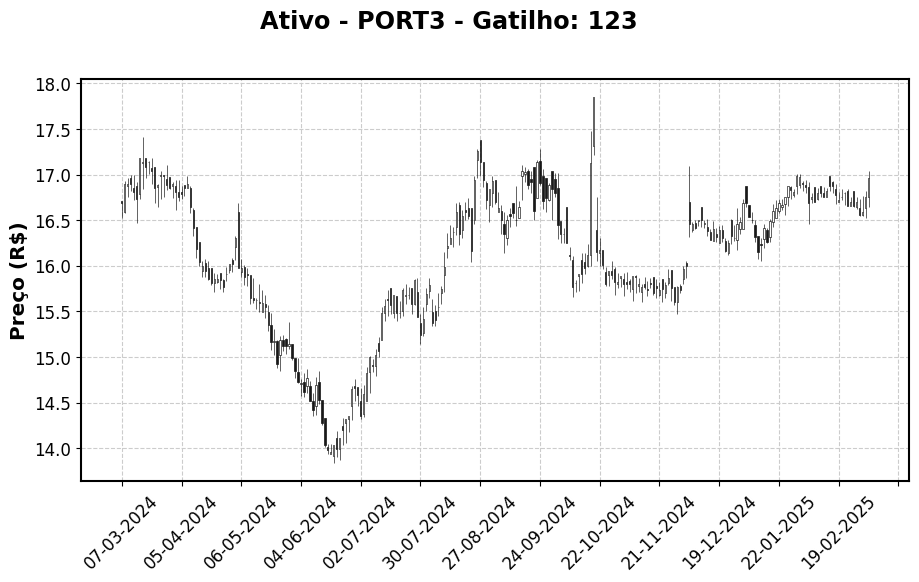

####################################################################
#### Empresa:  SCHULZ PN
#### Setor:  Máquinas e Equipamentos
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  5.94
#### Margem Bruta:  25.8%
#### Margem Liquida:  14.0%
#### Margem EBITDA 12.1%
#### ROE:  19.4%
#### EBITDA ultimo 12 meses:  235316000
#### Divida Bruta:  647528000
#### Divida Liquida:  -209619000
####################################################################
                                                                    


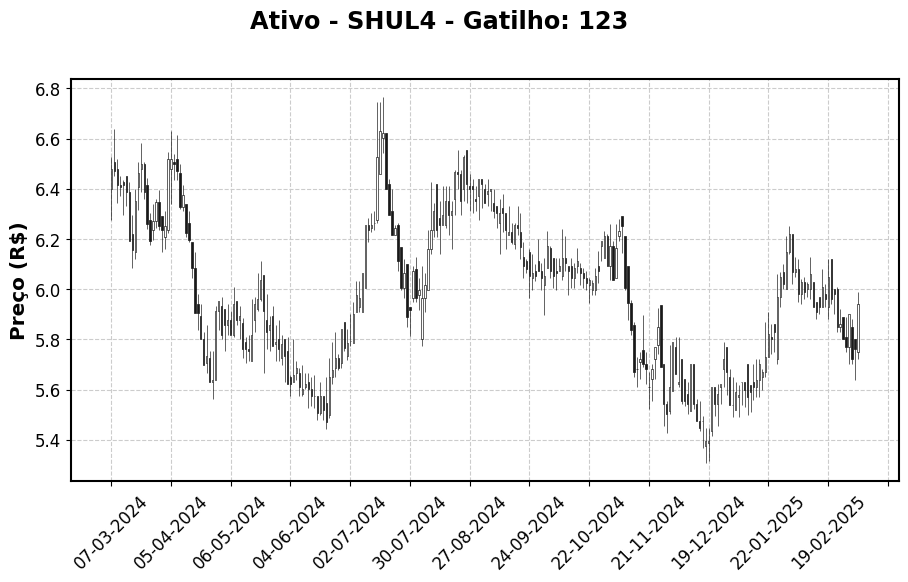

####################################################################
#### Empresa:  WEG SA ON N1
#### Setor:  Máquinas e Equipamentos
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  47.89
#### Margem Bruta:  33.7%
#### Margem Liquida:  16.6%
#### Margem EBITDA 22.4%
#### ROE:  27.2%
#### EBITDA ultimo 12 meses:  8527120000
#### Divida Bruta:  3595240000
#### Divida Liquida:  -4400840000
####################################################################
                                                                    


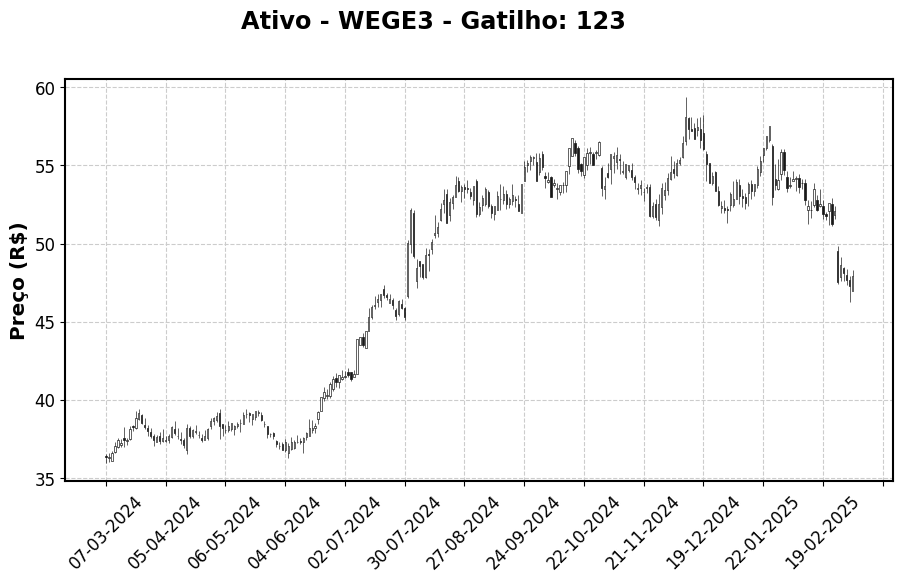

['CAMB3',
 'CEBR3',
 'CMIG4',
 'CSMG3',
 'CSUD3',
 'ENGI4',
 'INTB3',
 'KEPL3',
 'KLBN11',
 'KLBN3',
 'KLBN4',
 'MRSA3B',
 'PORT3',
 'SHUL4',
 'WEGE3']

In [ ]:
lista_acoes_gatilho_123(df_join)

## PROCESSA GATILHOS INSIDE CANDLE

####################################################################
#### Empresa:  COMPANHIA DE GÁS DE SÃO PAULO - COMGÁS ON
#### Setor:  Gás
#### Data ultima cotacao:  2025-03-07
#### Cotacao:  124.00
#### Margem Bruta:  21.5%
#### Margem Liquida:  11.6%
#### Margem EBITDA 18.7%
#### ROE:  158.1%
#### EBITDA ultimo 12 meses:  2886510000
#### Divida Bruta:  9789200000
#### Divida Liquida:  7600780000
####################################################################
                                                                    


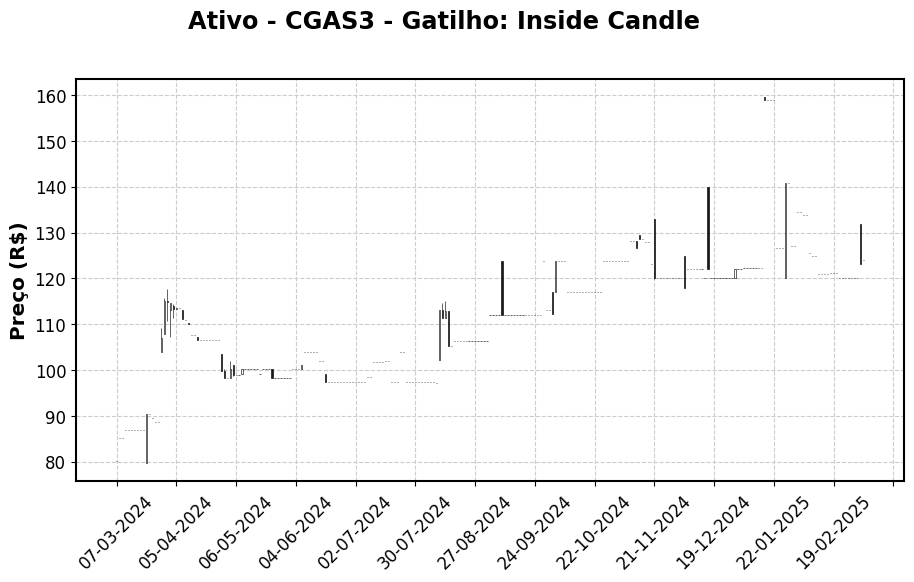

['CGAS3']

In [ ]:
lista_acoes_gatilho_inside_candle(df_join)